# 観測効果込みの実効的な速度分散$\sigma_\mathrm{eff}$がどうなるか測定しておく

$\sigma_\mathrm{gas}=[10, 50, 100]\ \mathrm{km\,s^{-1}}$のGaussian輝線をALMA FDMのnative channel gridで作り、`simobserve`で擬似観測する。

想定する観測
- Band 6  [CII] 158um at z=6  
- Bandwidth 1.875 GHz / 3840 channels、Hanning、online 8-channel averaging
- native channel幅 4.33 km/s → 6-channel averagingで25.97 km/s

`simobserve`はcorrelator responseを加えない。そのため、Hanningとonline averagingを入力FITSのspectrumへあらかじめ反映し、次の簡略化した処理を行う。

1. 4.33 km/s幅のnative-channel FITS → `simobserve`
2. `mstransform`で6 channelsを平均

thermal noiseは加えない。位相中心のunresolved sourceを使い、全baseline・polarizationの実部を平均してspectrum取得

In [1]:
from pathlib import Path
import os
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
from astropy.io import fits
import astropy.units as u
from scipy.optimize import curve_fit
from scipy.special import erf

from casatasks import casalog, mstransform, simobserve
from casatools import table

%matplotlib inline
casalog.filter('WARN')

SIGMA_GAS_KMS = np.array([10.0, 50.0, 100.0])
REST_FREQUENCY_CII_HZ = 1.9005369e12
SOURCE_REDSHIFT = 6.024
REFERENCE_FREQUENCY_HZ = REST_FREQUENCY_CII_HZ / (1.0 + SOURCE_REDSHIFT)
C_KMS = 299792.458

# ALMA FDM 1.875 GHz / 3840 channels。Hanning後にonline averaging N=8
FDM_BANDWIDTH_HZ = 1.875e9
FDM_RAW_CHANNELS = 3840
ONLINE_AVERAGING = 8
FINAL_AVERAGING = 6
RAW_CHANNEL_WIDTH_HZ = FDM_BANDWIDTH_HZ / FDM_RAW_CHANNELS
NATIVE_CHANNEL_WIDTH_HZ = ONLINE_AVERAGING * RAW_CHANNEL_WIDTH_HZ
RAW_CHANNEL_WIDTH_KMS = C_KMS * RAW_CHANNEL_WIDTH_HZ / REFERENCE_FREQUENCY_HZ
NATIVE_CHANNEL_WIDTH_KMS = ONLINE_AVERAGING * RAW_CHANNEL_WIDTH_KMS
FINAL_CHANNEL_WIDTH_KMS = FINAL_AVERAGING * NATIVE_CHANNEL_WIDTH_KMS

# 41個の最終channelsを作れるnative grid。Hanning計算用にraw gridは両端を1 channelずつ広げる。
N_FINAL_CHANNELS = 41
N_NATIVE_MODEL_CHANNELS = FINAL_AVERAGING * N_FINAL_CHANNELS
N_RAW_MODEL_CHANNELS = ONLINE_AVERAGING * N_NATIVE_MODEL_CHANNELS + 2
VELOCITY_RAW_KMS = (
    np.arange(N_RAW_MODEL_CHANNELS) - (N_RAW_MODEL_CHANNELS - 1) / 2
) * RAW_CHANNEL_WIDTH_KMS
VELOCITY_NATIVE_KMS = (
    np.arange(N_NATIVE_MODEL_CHANNELS) - (N_NATIVE_MODEL_CHANNELS - 1) / 2
) * NATIVE_CHANNEL_WIDTH_KMS

NX = NY = 9
PIXEL_SIZE_ARCSEC = 0.10
PEAK_FLUX_JY = 0.1
PHASE_CENTER_RA_DEG = 135.1909708333
PHASE_CENTER_DEC_DEG = 0.6897777778
phase_center = SkyCoord(PHASE_CENTER_RA_DEG * u.deg, PHASE_CENTER_DEC_DEG * u.deg, frame='icrs')
PHASE_CENTER_CASA = (
    'J2000 '
    + phase_center.ra.to_string(unit=u.hour, sep=':', precision=8, pad=True)
    + ' '
    + phase_center.dec.to_string(unit=u.deg, sep='.', precision=8, pad=True, alwayssign=True)
)

ANTENNA_CONFIG = Path('../examples/data/configuration_files/alma.cycle7.5.cfg').resolve()
if not ANTENNA_CONFIG.exists():
    raise FileNotFoundError('alma.cycle7.5.cfg was not found')

WORK = Path('/tmp/glint_simobserve_spectral_resolution_work')
if WORK.exists():
    shutil.rmtree(WORK)
WORK.mkdir(parents=True, exist_ok=True)

print('CASA antenna configuration:', ANTENNA_CONFIG)
print('raw correlator spacing:', f'{RAW_CHANNEL_WIDTH_KMS:.3f} km/s')
print('observed native spacing:', f'{NATIVE_CHANNEL_WIDTH_KMS:.3f} km/s')
print('final channel averaging:', FINAL_AVERAGING, 'channels ->', f'{FINAL_CHANNEL_WIDTH_KMS:.3f} km/s')
print('work directory:', WORK)

CASA antenna configuration: /lwk/atsujita/HATLASJ0900/glint/examples/data/configuration_files/alma.cycle7.5.cfg
raw correlator spacing: 0.541 km/s
observed native spacing: 4.328 km/s
final channel averaging: 6 channels -> 25.968 km/s
work directory: /tmp/glint_simobserve_spectral_resolution_work


## Native-resolution input sky models

各spectral planeの中央pixelだけにfluxを置く。sourceは位相中心にあるため、noiseなしvisibilityの実部は全baselineで同じspectral shapeを持つ。

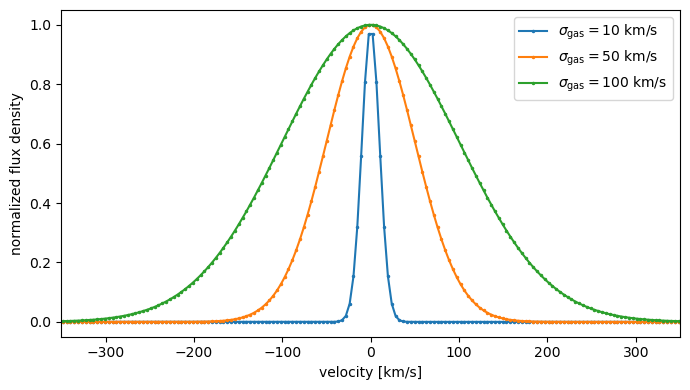

In [2]:
def gaussian_profile(velocity_kms, amplitude, center_kms, sigma_kms, offset):
    return offset + amplitude * np.exp(-0.5 * ((velocity_kms - center_kms) / sigma_kms) ** 2)


def channel_integrated_gaussian(velocity_kms, amplitude, center_kms, sigma_kms, offset, width_kms):
    lower = (velocity_kms - 0.5 * width_kms - center_kms) / (np.sqrt(2.0) * sigma_kms)
    upper = (velocity_kms + 0.5 * width_kms - center_kms) / (np.sqrt(2.0) * sigma_kms)
    average = (
        sigma_kms * np.sqrt(np.pi / 2.0) / width_kms
        * (erf(upper) - erf(lower))
    )
    return offset + amplitude * average


def make_native_spectrum(sigma_gas_kms):
    raw_spectrum = channel_integrated_gaussian(
        VELOCITY_RAW_KMS, PEAK_FLUX_JY, 0.0, sigma_gas_kms, 0.0, RAW_CHANNEL_WIDTH_KMS
    )
    hanning_spectrum = np.convolve(raw_spectrum, [0.25, 0.5, 0.25], mode='valid')
    return hanning_spectrum.reshape(N_NATIVE_MODEL_CHANNELS, ONLINE_AVERAGING).mean(axis=1)


def write_input_cube(path, sigma_gas_kms):
    spectrum = make_native_spectrum(sigma_gas_kms)
    cube = np.zeros((VELOCITY_NATIVE_KMS.size, NY, NX), dtype=np.float32)
    cube[:, NY // 2, NX // 2] = spectrum

    frequencies_hz = REFERENCE_FREQUENCY_HZ * (1.0 - VELOCITY_NATIVE_KMS / C_KMS)
    order = np.argsort(frequencies_hz)
    frequencies_hz = frequencies_hz[order]
    cube = cube[order]

    header = fits.Header()
    header['BUNIT'] = 'Jy/pixel'
    header['BTYPE'] = 'Intensity'
    header['RADESYS'] = 'ICRS'
    header['SPECSYS'] = 'LSRK'
    # このworkflowでは、redshift後のobserved-frame基準周波数をRESTFRQとする。
    header['RESTFRQ'] = REFERENCE_FREQUENCY_HZ
    header['CTYPE1'], header['CTYPE2'], header['CTYPE3'] = 'RA---SIN', 'DEC--SIN', 'FREQ'
    header['CUNIT1'], header['CUNIT2'], header['CUNIT3'] = 'deg', 'deg', 'Hz'
    header['CRVAL1'], header['CRVAL2'] = PHASE_CENTER_RA_DEG, PHASE_CENTER_DEC_DEG
    header['CRPIX1'], header['CRPIX2'] = (NX + 1.0) / 2.0, (NY + 1.0) / 2.0
    header['CRVAL3'], header['CRPIX3'] = frequencies_hz[0], 1.0
    header['CDELT1'] = -PIXEL_SIZE_ARCSEC / 3600.0
    header['CDELT2'] = PIXEL_SIZE_ARCSEC / 3600.0
    header['CDELT3'] = NATIVE_CHANNEL_WIDTH_HZ

    path.parent.mkdir(parents=True, exist_ok=True)
    fits.writeto(path, cube, header=header, overwrite=True)
    return path


input_paths = {}
fig, ax = plt.subplots(figsize=(7, 4))
for sigma_gas in SIGMA_GAS_KMS:
    case_dir = WORK / f'sigma_{int(sigma_gas):03d}'
    input_paths[sigma_gas] = write_input_cube(case_dir / 'input_cube.fits', sigma_gas)
    ax.plot(
        VELOCITY_NATIVE_KMS,
        make_native_spectrum(sigma_gas) / PEAK_FLUX_JY,
        marker='.', ms=3,
        label=fr'$\sigma_{{\rm gas}}={sigma_gas:.0f}$ km/s',
    )
ax.set(xlabel='velocity [km/s]', ylabel='normalized flux density', xlim=(-350, 350))
ax.legend()
plt.tight_layout(); plt.show()

## CASA `simobserve` and final channel averaging

入力FITSはHanningと8-channel online averagingをすでに含む。`simobserve`はそのnative spectral planesをvisibilityへ変換し、`mstransform`では最後の6-channel averagingだけを行う。

In [3]:
def find_signal_ms(project_dir):
    candidates = sorted(
        path for path in project_dir.glob('*.ms')
        if not path.name.endswith('.noisy.ms')
    )
    if len(candidates) != 1:
        raise RuntimeError(f'unexpected simobserve MS products: {candidates}')
    return candidates[0]


def run_case(sigma_gas_kms, input_fits):
    case_dir = WORK / f'sigma_{int(sigma_gas_kms):03d}'
    project_dir = case_dir / 'simobserve'
    original_directory = Path.cwd()
    try:
        os.chdir(case_dir)
        simobserve(
            project=project_dir.name,
            skymodel=str(input_fits.resolve()),
            indirection='', incell='', incenter='',
            inwidth='',  # FITS headerのCDELT3を使用
            setpointings=True,
            integration='10s',
            direction=PHASE_CENTER_CASA,
            mapsize=['1arcsec', '1arcsec'],
            obsmode='int',
            antennalist=str(ANTENNA_CONFIG),
            refdate='2022/01/15',
            hourangle='0h',
            totaltime='10s',
            thermalnoise='',
            seed=20260814,
            graphics='none',
            verbose=False,
            overwrite=True,
        )
    finally:
        os.chdir(original_directory)

    native_ms = find_signal_ms(project_dir)
    averaged_ms = case_dir / 'averaged_6ch.ms'
    mstransform(
        vis=str(native_ms), outputvis=str(averaged_ms), datacolumn='data',
        chanaverage=True, chanbin=FINAL_AVERAGING, hanning=False,
        keepflags=True, usewtspectrum=True,
    )
    return {
        'native (simobserve)': native_ms,
        '6-channel average': averaged_ms,
    }


products = {}
for sigma_gas in SIGMA_GAS_KMS:
    print(f'running sigma_gas={sigma_gas:.0f} km/s')
    products[sigma_gas] = run_case(sigma_gas, input_paths[sigma_gas])
print('CASA products are ready.')

running sigma_gas=10 km/s
running sigma_gas=50 km/s
running sigma_gas=100 km/s
CASA products are ready.


## Visibility spectrum fitting

二つのfitを行う。

- **center-sampled Gaussian fit**: channel中心の値を通常のGaussianとしてfitし、見かけの$\sigma_\mathrm{eff}$を測る。
- **channel-integrated Gaussian fit**: 実際のchannel幅でGaussianを積分したmodelをfitする。`glint.source.make_rotating_disk_cube`と同じ考え方であり、最終channel積分を除いた残りの幅が`spec_res_sgm_kms`に対応する。

In [4]:
def read_ms_spectrum(ms_path):
    tb = table()
    try:
        tb.open(str(ms_path))
        data = np.asarray(tb.getcol('DATA'))
        flag = np.asarray(tb.getcol('FLAG'), dtype=bool)
        if 'WEIGHT_SPECTRUM' in tb.colnames():
            weight = np.asarray(tb.getcol('WEIGHT_SPECTRUM'), dtype=float)
        else:
            weight = np.asarray(tb.getcol('WEIGHT'), dtype=float)[:, None, :]
    finally:
        tb.close()

    valid = (~flag) & np.isfinite(weight) & (weight > 0)
    effective_weight = np.where(valid, weight, 0.0)
    weight_sum = effective_weight.sum(axis=(0, 2))
    real_spectrum = np.divide(
        (data.real * effective_weight).sum(axis=(0, 2)), weight_sum,
        out=np.full(weight_sum.shape, np.nan, dtype=float), where=weight_sum > 0,
    )
    try:
        tb.open(str(Path(ms_path) / 'SPECTRAL_WINDOW'))
        frequencies_hz = np.asarray(tb.getcol('CHAN_FREQ'), dtype=float).squeeze()
    finally:
        tb.close()
    velocity_kms = C_KMS * (1.0 - frequencies_hz / REFERENCE_FREQUENCY_HZ)
    order = np.argsort(velocity_kms)
    return velocity_kms[order], real_spectrum[order]


def fit_profile(velocity_kms, spectrum, sigma_guess, *, integrate_channels=False):
    valid = np.isfinite(velocity_kms) & np.isfinite(spectrum)
    x = velocity_kms[valid]
    y = spectrum[valid]
    y = y / np.max(y)
    edge = np.r_[y[:3], y[-3:]]
    offset_guess = float(np.median(edge))
    initial = [1.0 - offset_guess, x[np.argmax(y)], sigma_guess, offset_guess]
    bounds = ([0.0, -50.0, 0.1, -0.2], [2.0, 50.0, 300.0, 0.2])
    width_kms = float(abs(np.median(np.diff(x))))
    if integrate_channels:
        model = lambda velocity, amplitude, center, sigma, offset: channel_integrated_gaussian(
            velocity, amplitude, center, sigma, offset, width_kms
        )
    else:
        model = gaussian_profile
    parameters, _ = curve_fit(
        model, x, y, p0=initial, bounds=bounds, maxfev=20000,
    )
    return {'parameters': parameters, 'channel_spacing_kms': width_kms}


fits_by_case = {}
rows = []
for sigma_gas, case_products in products.items():
    fits_by_case[sigma_gas] = {}
    for processing, ms_path in case_products.items():
        velocity, real_spectrum = read_ms_spectrum(ms_path)
        point_fit = fit_profile(velocity, real_spectrum, sigma_gas)
        integrated_fit = fit_profile(
            velocity, real_spectrum, sigma_gas, integrate_channels=True,
        )
        sigma_point = float(point_fit['parameters'][2])
        sigma_integrated = float(integrated_fit['parameters'][2])
        fits_by_case[sigma_gas][processing] = {
            'velocity': velocity, 'real': real_spectrum,
            'point_fit': point_fit, 'integrated_fit': integrated_fit,
        }
        rows.append({
            'sigma_gas_input_kms': sigma_gas,
            'processing': processing,
            'channel_spacing_kms': point_fit['channel_spacing_kms'],
            'sigma_eff_center_sampled_fit_kms': sigma_point,
            'sigma_channel_integrated_fit_kms': sigma_integrated,
        })

results = pd.DataFrame(rows)
results['boxcar_quadrature_prediction_kms'] = np.sqrt(
    results['sigma_gas_input_kms']**2 + results['channel_spacing_kms']**2 / 12.0
)
display_columns = [
    'sigma_gas_input_kms', 'processing', 'channel_spacing_kms',
    'sigma_eff_center_sampled_fit_kms', 'sigma_channel_integrated_fit_kms',
    'boxcar_quadrature_prediction_kms',
]
display(results[display_columns].round(4))

# 実験が意図したspectral responseを保っていることを自動確認する。
native = results[results['processing'] == 'native (simobserve)']
averaged = results[results['processing'] == '6-channel average']
narrow_averaged = averaged[np.isclose(averaged['sigma_gas_input_kms'], 10.0)].iloc[0]
inferred_resolution_sigma_kms = np.sqrt(
    narrow_averaged['sigma_channel_integrated_fit_kms']**2
    - narrow_averaged['sigma_gas_input_kms']**2
)
print('instrumental sigma inferred from the 10 km/s line:', f'{inferred_resolution_sigma_kms:.3f} km/s')
np.testing.assert_allclose(
    native['channel_spacing_kms'], NATIVE_CHANNEL_WIDTH_KMS, atol=1e-3,
)
np.testing.assert_allclose(
    averaged['channel_spacing_kms'], FINAL_CHANNEL_WIDTH_KMS, atol=1e-3,
)
np.testing.assert_allclose(
    native['sigma_channel_integrated_fit_kms'], native['sigma_gas_input_kms'], atol=0.03,
)
np.testing.assert_allclose(
    averaged['sigma_channel_integrated_fit_kms'], averaged['sigma_gas_input_kms'], atol=0.03,
)
np.testing.assert_allclose(
    inferred_resolution_sigma_kms,
    RAW_CHANNEL_WIDTH_KMS / np.sqrt(2.0), atol=0.01,
)

,sigma_gas_input_kms,processing,channel_spacing_kms,sigma_eff_center_sampled_fit_kms,sigma_channel_integrated_fit_kms,boxcar_quadrature_prediction_kms
0,10.0,native (simobserve),4.3280,10.0854,10.0073,10.0777
1,10.0,6-channel average,25.9681,12.6267,10.0073,12.4978
2,50.0,native (simobserve),4.3280,50.0171,50.0015,50.0156
3,50.0,6-channel average,25.9681,50.5642,50.0015,50.5588
4,100.0,native (simobserve),4.3280,100.0091,100.0013,100.0078
5,100.0,6-channel average,25.9681,100.2824,100.0013,100.2806


instrumental sigma inferred from the 10 km/s line: 0.383 km/s


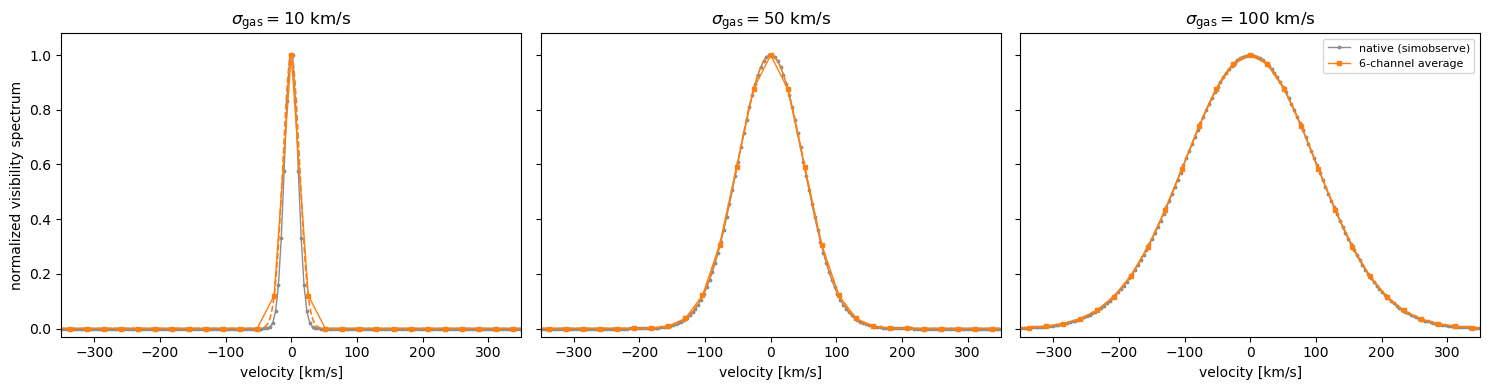

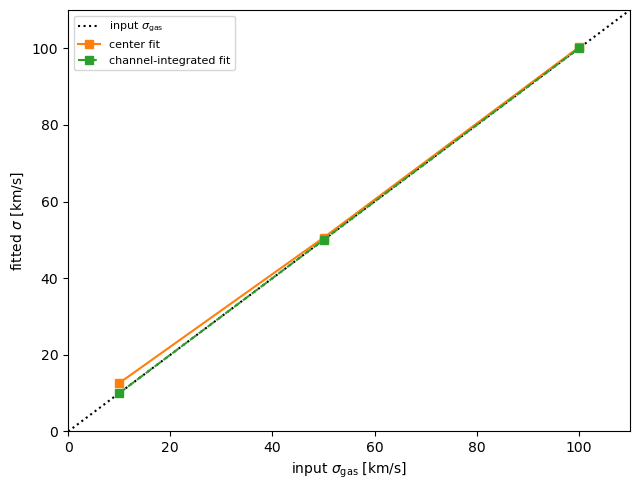

In [6]:
colors = {'native (simobserve)': '0.55', '6-channel average': 'C1'}
markers = {'native (simobserve)': '.', '6-channel average': 's'}
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, sigma_gas in zip(axes, SIGMA_GAS_KMS):
    for processing, fit_data in fits_by_case[sigma_gas].items():
        velocity = fit_data['velocity']
        spectrum = fit_data['real'] / np.nanmax(fit_data['real'])
        point_fit = fit_data['point_fit']
        ax.plot(
            velocity, spectrum, marker=markers[processing], color=colors[processing],
            ms=3.5, lw=1.0, label=processing,
        )
        if processing == '6-channel average':
            fine_velocity = np.linspace(-400.0, 400.0, 1601)
            ax.plot(
                fine_velocity,
                gaussian_profile(fine_velocity, *point_fit['parameters']),
                color=colors[processing], ls='--', lw=1.2,
            )
    ax.set(
        title=fr'$\sigma_{{\rm gas}}={sigma_gas:.0f}$ km/s',
        xlabel='velocity [km/s]', xlim=(-350, 350), ylim=(-0.03, 1.08),
    )
axes[0].set_ylabel('normalized visibility spectrum')
axes[-1].legend(fontsize=8)
plt.tight_layout(); plt.show()

averaged_results = results[results['processing'] == '6-channel average']
fig, ax = plt.subplots(figsize=(6.5, 5))
grid = np.linspace(0, 110, 200)
ax.plot(grid, grid, 'k:', label='input $\sigma_\mathrm{gas}$')
ax.plot(
    averaged_results['sigma_gas_input_kms'], averaged_results['sigma_eff_center_sampled_fit_kms'],
    marker='s', color='C1', label='center fit',
)
ax.plot(
    averaged_results['sigma_gas_input_kms'], averaged_results['sigma_channel_integrated_fit_kms'],
    marker='s', color='C2', ls='--', label='channel-integrated fit',
)
ax.set(xlabel='input $\sigma_\mathrm{gas}$ [km/s]', ylabel='fitted $\sigma$ [km/s]', xlim=(0, 110), ylim=(0, 110))
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 結論

- 厳密には、$\sigma_\mathrm{eff} = \sqrt{\sigma_\mathrm{gas}^2+\Delta V^2/12 + \delta v^2 /2}$ が正しいと思われる。
- 第２項はchannel averagingによるboxcarの分散（boxcar畳み込み後のprofileは厳密なGaussianでないから少しだけズレる）、第３項はnative resolutionをHanning smoothing（ALMAの場合Kernelは$(0.25,0.5,0.25)$）したことによる分散で、ALMAの場合小さいので無視できる (0.383$ km/s くらいになる)
- channel積分込みfitでは最終channel averagingをmodel側で扱うため、入力幅を回収する。現在のforward modelも同じ積分を行うので、boxcar効果を`spec_res_sgm_kms`へ重ねて入れてはいけない。

したがって、まあある程度$\sigma_\mathrm{gas} > \Delta V$ の場合、channel averagingの効果はほぼ無視できる。`spec_res_sgm_kms`にチャンネル幅を入れてはダメ！（3D Baroloの実装間違ってね？）